In [6]:
import pandas as pd
import numpy as np

# dataset
data = {
    'student_name': ['alice', 'bob', 'mukesh', 'paras', 'basanta', 'bob'],
    'hours_studied': [5, 8, 10, 6, 7, 8],
    'previous_score': [65, 85, 99, 84, 76, 85],
    'attendance': ['yes', 'NO', 'yes', 'NO', 'yes', 'NO'],
    'sleep_hours': [7, 5, 4, 7, 8, 5],
    'extracurricular': ['yes', 'NO', 'yes', 'NO', 'yes', 'NO'],
    'parameter_education': ['bachelor', 'master', 'phd', 'high school', 'bachelor', 'master']
}

df = pd.DataFrame(data)

print("Student Performance DataFrame:")
print(df)

# basic info
print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)


Student Performance DataFrame:
  student_name  hours_studied  previous_score attendance  sleep_hours  \
0        alice              5              65        yes            7   
1          bob              8              85         NO            5   
2       mukesh             10              99        yes            4   
3        paras              6              84         NO            7   
4      basanta              7              76        yes            8   
5          bob              8              85         NO            5   

  extracurricular parameter_education  
0             yes            bachelor  
1              NO              master  
2             yes                 phd  
3              NO         high school  
4             yes            bachelor  
5              NO              master  

Shape: (6, 7)
Columns: ['student_name', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parameter_education']

Data types:
 student_name    

In [7]:
# first/last rows
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 2 rows:")
print(df.tail(2))

# stats
print("\nStatistical Summary:")
print(df.describe())

# missing values
print("\nMissing Values:")
print(df.isnull().sum())

# duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# ---- FIX 1: convert attendance to numeric ----
df['attendance_num'] = df['attendance'].map({'yes': 100, 'NO': 0})

# ---- derived features ----
df['total_study_effort'] = df['hours_studied'] * (df['attendance_num'] / 100)
df['sleep_quality'] = df['sleep_hours'] / 8

# grade function
def calculate_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['grade'] = df['previous_score'].apply(calculate_grade)

# ---- FIX 2: correct mapping ----
df['extracurricular_num'] = df['extracurricular'].map({'yes': 1, 'NO': 0})

print("\nFinal DataFrame:")
print(df)


First 5 rows:
  student_name  hours_studied  previous_score attendance  sleep_hours  \
0        alice              5              65        yes            7   
1          bob              8              85         NO            5   
2       mukesh             10              99        yes            4   
3        paras              6              84         NO            7   
4      basanta              7              76        yes            8   

  extracurricular parameter_education  
0             yes            bachelor  
1              NO              master  
2             yes                 phd  
3              NO         high school  
4             yes            bachelor  

Last 2 rows:
  student_name  hours_studied  previous_score attendance  sleep_hours  \
4      basanta              7              76        yes            8   
5          bob              8              85         NO            5   

  extracurricular parameter_education  
4             yes            bac

In [11]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 500

# Generate features
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# Create final score based on realistic formula
# This is what our ML model will try to learn tomorrow!
df_students['final_score'] = (
    df_students['hours_studied'] * 2.5 +           # Each study hour adds ~2.5 points
    df_students['previous_score'] * 0.5 +          # Previous score has 50% weight
    df_students['attendance'] * 0.3 +              # Attendance adds ~0.3 points per %
    df_students['sleep_hours'] * 1.5 +             # Good sleep adds up to ~15 points
    (df_students['extracurricular'] == 'Yes') * 5 + # Extracurricular bonus: 5 points
    (df_students['internet_access'] == 'Yes') * 3 + # Internet access bonus: 3 points
    np.random.normal(0, 5, n_students)             # Random noise (realism)
).clip(0, 100).round(2)  # Keep scores between 0-100

print("✅ Synthetic Student Dataset Created!")
print("Dataset Shape:", df_students.shape)
print("Number of Students:", len(df_students))
print("Features:", df_students.columns.tolist())

print("\nFirst 10 rows:")
print(df_students.head(10))

print("\nStatistical Summary:")
print(df_students.describe())

✅ Synthetic Student Dataset Created!
Dataset Shape: (500, 9)
Number of Students: 500
Features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']

First 10 rows:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   
5           6             13              81          51          4.6   
6           7              5              45          60          8.8   
7           8              7              54          88          5.1   
8           9             10              93          87          7.9   
9      

In [15]:
 
import pandas as pd

np.random.seed(42)
n_students = 500

# dataset with FINAL SCORE included
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# 🔥 Create synthetic final_score (VERY IMPORTANT)
df_students['final_score'] = (
    df_students['hours_studied'] * 2 +
    df_students['attendance'] * 0.3 +
    df_students['previous_score'] * 0.5 +
    np.random.randint(-10, 10, n_students)
)


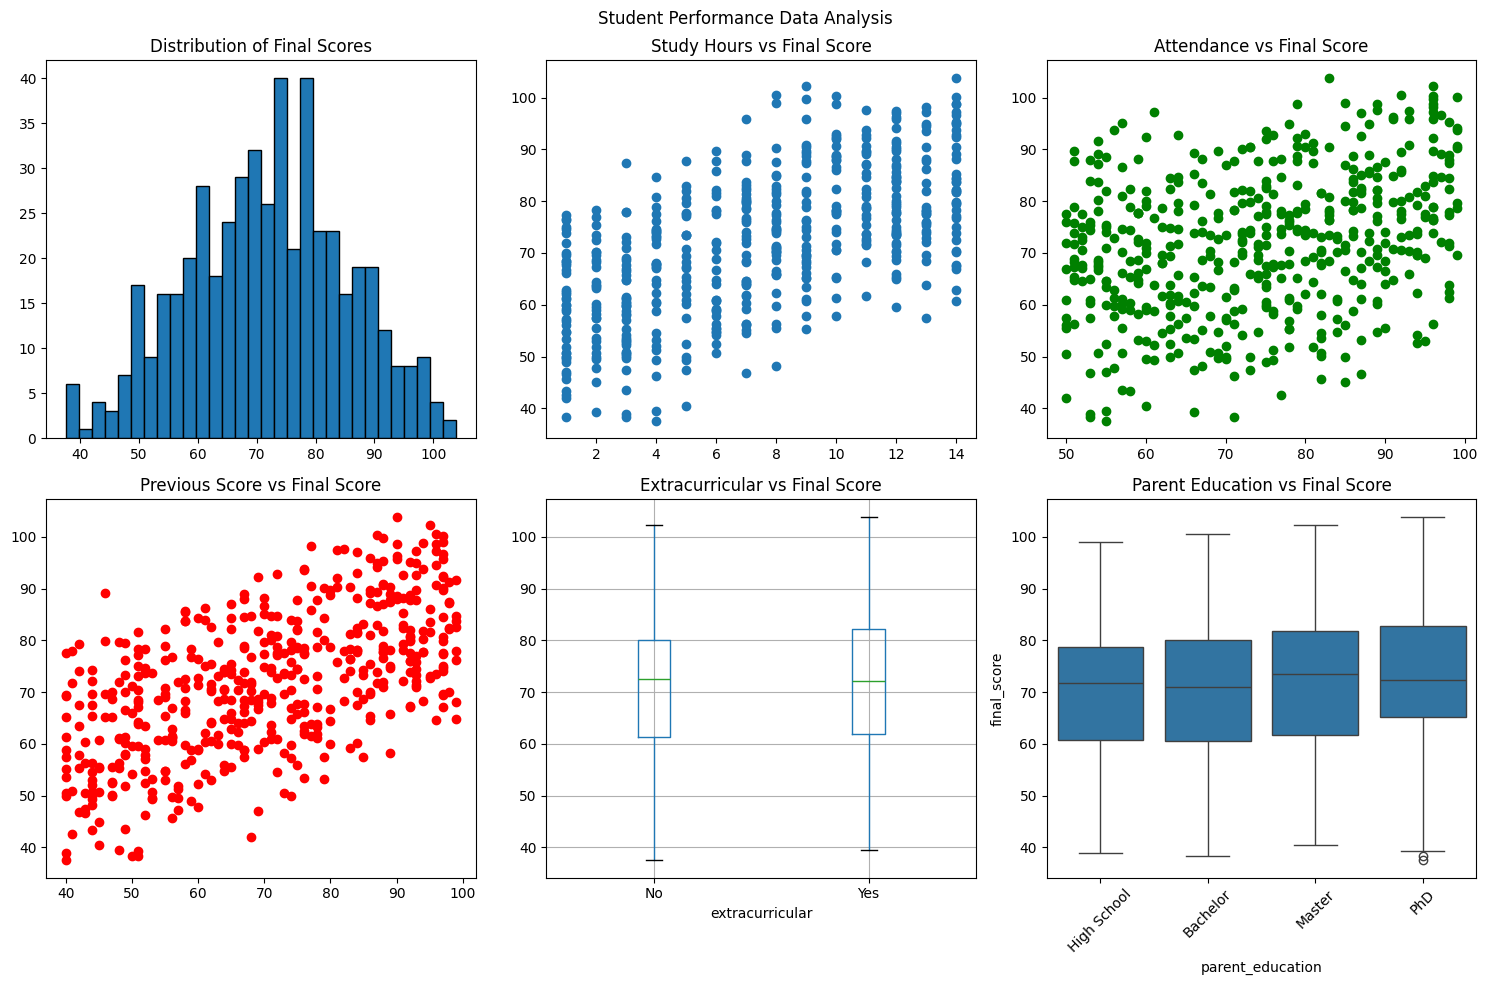


📊 Observations:
1. Study hours strongly affect performance
2. Attendance improves final score
3. Previous score is a strong predictor
4. Extracurricular students perform slightly better
5. Education background impacts performance


In [16]:
# Create visualizations to understand the data
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(df_students['final_score'], bins=30, edgecolor='black')
axes[0, 0].set_title('Distribution of Final Scores')

axes[0, 1].scatter(df_students['hours_studied'], df_students['final_score'])
axes[0, 1].set_title('Study Hours vs Final Score')

axes[0, 2].scatter(df_students['attendance'], df_students['final_score'], color='green')
axes[0, 2].set_title('Attendance vs Final Score')

axes[1, 0].scatter(df_students['previous_score'], df_students['final_score'], color='red')
axes[1, 0].set_title('Previous Score vs Final Score')

df_students.boxplot(column='final_score', by='extracurricular', ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular vs Final Score')

education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(
    x='parent_education',
    y='final_score',
    data=df_students,
    order=education_order,
    ax=axes[1, 2]
)

axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_title('Parent Education vs Final Score')

plt.suptitle('Student Performance Data Analysis')
plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("1. Study hours strongly affect performance")
print("2. Attendance improves final score")
print("3. Previous score is a strong predictor")
print("4. Extracurricular students perform slightly better")
print("5. Education background impacts performance")
